<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Fashion_MNIST_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project overview
The objective of this project is to develop the most optimal MLP model through grid search of hyper-parameters that classifies grayscale images of fashion products into ten categories.
The project uses the Fashion-MNIST dataset, which contains \(28 * 28\)-pixel grayscale images of clothing and footwear.


This project will compare 8 deep-learning models with the following hyper-parameters:


Learning_rate,	Width,	Dropout

- 0.0001,  64,  0.0
- 0.0001,	 64,  0.3
- 0.0001,	256,	0.0
- 0.0001,	256,	0.3
- 0.001,	 64,	0.0
- 0.001,	 64,	0.3
- 0.001,	256,	0.0
- 0.001,	256,	0.3

### Business-style problem definition
Imagine an online clothing retailer that receives large numbers of product images. Each image must be assigned to a product category before it can be displayed, searched or recommended to customers.
Manually assigning these categories would be:
- Slow
- Expensive
- Inconsistent
- Difficult to scale
The machine-learning task is therefore to create an automated image-classification system that predicts the correct product category from a grayscale image.


### Machine-learning problem
This is a supervised multiclass image-classification problem.
For every image, the model predicts one of ten possible classes from 0 to 9.

### Dataset
- Fashion-MNIST contains 70,000 grayscale images.
- Dataset portion	Number of images
- Original training set	60,000
- Original test set	10,000
- Image size	(28 * 28)
- Number of classes	10


Each pixel has an intensity value between 0 and 255.

Class definitions

Label	Product category
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot


The dataset can be loaded directly through Keras:
from tensorflow.keras.datasets import fashion_mnist

(x_all, y_all), (x_test, y_test) = (
    fashion_mnist.load_data()
)

where x_all and y_all could be used for the training and validation parts altogether.


# Main project objective
The main objective is to build the best deep-learning model across 8 combinations of the above-mentioned hyper-parameters.



In [21]:
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
import numpy as np

In [11]:
(x_all, y_all), (x_test, y_test) = (fashion_mnist.load_data())
print(x_all.shape)
print(x_test.shape)
print(y_all.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [12]:
# First, we create a random index array and extract the training and validation
# parts out of x_all and y_all and normalize them

SEED = 42
rng = np.random.default_rng(SEED)

indices = rng.permutation(len(x_all))

val_indices = indices[:10000]
train_indices = indices[10000:]

x_val = x_all[val_indices].astype(np.float32)/ 255.0
y_val = y_all[val_indices]

x_train = x_all[train_indices].astype(np.float32)/ 255.0
y_train = y_all[train_indices]

x_test = x_test.astype(np.float32)/ 255.0


In [15]:
def build_model(width):

  model = Sequential([
      Input(shape = (28, 28)),
      Flatten(),
      Dense(width, activation = 'relu'),
      BatchNormalization(),

      Dense(10, activation = 'softmax')])

  model.compile(
      optimizer = Adam(learning_rate = 0.001),
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model

In [22]:
ES = EarlyStopping(
    monitor = 'val_loss',
    patience = 8,
    verbose = 1,
    restore_best_weights = True,
    mode = 'min'
)

model = build_model(64)

history = model.fit(x_train, y_train,
          epochs = 20,
          validation_data = (x_val, y_val),
          batch_size = 128,
          verbose = 1,
          callbacks = [ES])



Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8165 - loss: 0.5381 - val_accuracy: 0.8487 - val_loss: 0.4340
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8625 - loss: 0.3886 - val_accuracy: 0.8596 - val_loss: 0.3896
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8746 - loss: 0.3532 - val_accuracy: 0.8664 - val_loss: 0.3689
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8806 - loss: 0.3311 - val_accuracy: 0.8528 - val_loss: 0.4105
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8856 - loss: 0.3151 - val_accuracy: 0.8493 - val_loss: 0.4063
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8903 - loss: 0.3024 - val_accuracy: 0.8762 - val_loss: 0.3393
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8956 - loss: 0.2858 - val_accuracy: 0.8787 - val_loss: 0.3411
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8982 - loss: 0.2806 - val_accuracy: 0.

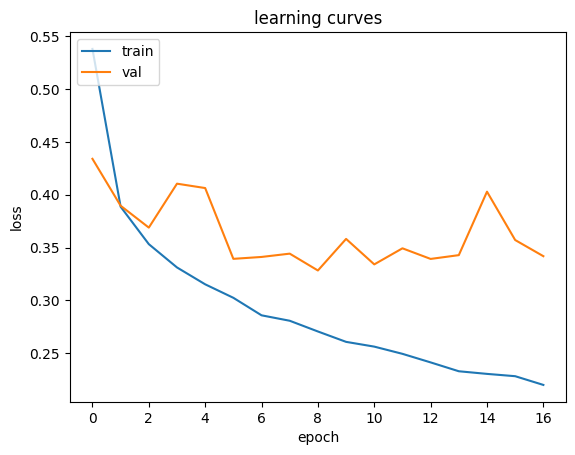

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('learning curves')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [43]:
best_weights = model.get_weights()
for i in range(8):
  print(best_weights[i].shape)

(784, 64)
(64,)
(64,)
(64,)
(64,)
(64,)
(64, 10)
(10,)


In [44]:
for w in best_weights:
    print(
        w.shape,
        "mean:", w.mean(),
        "std:", w.std(),
        "min:", w.min(),
        "max:", w.max()
    )

(784, 64) mean: -0.006169814 std: 0.0784791 min: -0.5096117 max: 0.4377527
(64,) mean: 0.16847493 std: 0.11059828 min: -0.026097182 max: 0.37102786
(64,) mean: 1.2827213 std: 0.13788848 min: 0.8812775 max: 1.6434247
(64,) mean: -0.008141923 std: 0.08653587 min: -0.1853035 max: 0.1634826
(64,) mean: 0.49318573 std: 0.7098131 min: 1.1715155e-19 max: 5.1128197
(64,) mean: 0.47110182 std: 1.0540113 min: 4.3679914e-16 max: 8.437808
(64, 10) mean: -0.026345868 std: 0.2507285 min: -0.63714445 max: 0.62876344
(10,) mean: -0.018432882 std: 0.07143737 min: -0.11527314 max: 0.09666718
